# **Step 0. Importing packages and functions**

In [3]:
# Importing extra packages
import os
import cftime
import numpy as np
import xarray as xr

from dask.diagnostics import ProgressBar
import warnings
warnings.simplefilter("ignore")
# for skiping running a certain cell
from IPython.core.magic import register_cell_magic

@register_cell_magic
def comment(line, cell):
    return

# for getting ot the right directory
import sys

#importing the necessary functions
sys.path.append("/nird/home/chrikap/Atmosphere_Ocean_Interactions_PhD/functions/nird_functions")
from ocean_functions import*

In [4]:
# Function for calculating the OHC

def ohc_funct_dV(model, weighted_temperature):
    
    rho = 1035 #kg/m^3   , values taken from: https://agupubs.onlinelibrary.wiley.com/doi/epdf/10.1029/2020GL091439 +++
    c_p = 4000 #J/(kg*C)
        
    if model == 'NorESM2-LM':
        ohc = weighted_temperature.sum(dim=("lev", "j", "i"))*rho*c_p
    elif model == 'IPSL-CM6A-LR':
        ohc = weighted_temperature.sum(dim=("olevel", 'y', 'x'))*rho*c_p
    elif model == 'CESM2':
        ohc = weighted_temperature.sum(dim=("lev", "nlat", "nlon"))*rho*c_p

    else:
        print('not a model here')
    return ohc

# **A. NorESM2**

## **1. Importing the potential temperature from NIRD and changing the units from C-> K**

*we're using the yarly_avg_manual function for turning monthly -> yearly means. 

It operates the same as yearly_avg, weighting every month with the number of its days. But it doesn'y use .groupby which adds on dask graph layers.

In [ ]:
experiments = ['piControl', 'abrupt-4xCO2']

for experiment in experiments:
            
    folder_path = f'/projects/NS9034K/CMIP6/CMIP/NCC/NorESM2-LM/{experiment}/r1i1p1f1/Omon/thetao/gr/latest/'

    file_names = sorted(os.listdir(folder_path))
    
    datasets = [xr.open_dataset(os.path.join(folder_path, file_name), chunks={'time': 12}) for file_name in file_names if file_name.endswith('.nc')]
    
    # Merge all the datasets in the list along the same dimension
    merged_datasets = xr.concat(datasets, dim='time')

    ds = merged_datasets.isel(time=slice(0, 500*12))

    ds = ds.chunk({
        "time": 120,      
        "lev": 10,    
        "j": 100,
        "i": 100
    })

    yearly_thetao = yearly_avg_manual('NorESM2-LM', ds)
    
    if experiment == 'piControl':
    
        thetao_piControl_noresm2 = yearly_thetao
    else: 
        thetao_x4CO2_noresm2 = yearly_thetao

In [4]:
thetao_K_piControl_noresm2 = thetao_piControl_noresm2 + 273.15
thetao_K_x4CO2_noresm2 = thetao_x4CO2_noresm2 + 273.15

## **2. Picking up the temperature values for the levels of interest**

In [5]:
## # picking up the area between surf.- 750m and 750-bottom

thetao_upper_750_noresm2_pi = thetao_K_piControl_noresm2['thetao'].where(thetao_K_piControl_noresm2.lev <= 750, drop=True)
thetao_upper_750_noresm2_x4 = thetao_K_x4CO2_noresm2['thetao'].where(thetao_K_x4CO2_noresm2.lev <= 750, drop=True)

thetao_lower_750_noresm2_pi = thetao_K_piControl_noresm2['thetao'].where(thetao_K_piControl_noresm2.lev > 750, drop=True)
thetao_lower_750_noresm2_x4 = thetao_K_x4CO2_noresm2['thetao'].where(thetao_K_x4CO2_noresm2.lev > 750, drop=True)

# picking up the area between surf.- 500m and 500-bottom

thetao_upper_500_noresm2_pi = thetao_K_piControl_noresm2['thetao'].where(thetao_K_piControl_noresm2.lev <= 500, drop=True)
thetao_upper_500_noresm2_x4 = thetao_K_x4CO2_noresm2['thetao'].where(thetao_K_x4CO2_noresm2.lev <= 500, drop=True)

thetao_lower_500_noresm2_pi = thetao_K_piControl_noresm2['thetao'].where(thetao_K_piControl_noresm2.lev > 500, drop=True)
thetao_lower_500_noresm2_x4 = thetao_K_x4CO2_noresm2['thetao'].where(thetao_K_x4CO2_noresm2.lev > 500, drop=True)

## **3. Preparing for the integration**

### **3.1. Getting the values of the integrating area from NIRD**

We will multiply this with dz later to get dV.

Note that the dV can be acquired directy from the volcello parameter. But it is not available for all 3 models. 

In [6]:
os.chdir(f'/projects/NS9034K/CMIP6/CMIP/NCC/NorESM2-LM/piControl/r1i1p1f1/Ofx/areacello/gn/latest')

areacello_noresm2 = xr.open_dataset('areacello_Ofx_NorESM2-LM_piControl_r1i1p1f1_gn.nc')
areacello_noresm2 = areacello_noresm2['areacello']

### **3.2. Getting dZ**

In [7]:
# Bounds
lev_bounds_noresm2 = yearly_thetao.lev_bnds[0, :, :]#.values 

#dask compute
lev_bounds_noresm2 = lev_bounds_noresm2.compute() 

## 750 m checkpoint

upper_750_noresm2 = lev_bounds_noresm2.where(lev_bounds_noresm2.lev <= 750, drop = True) #upper level bounds, up to 750 m
lower_750_noresm2 = lev_bounds_noresm2.where(lev_bounds_noresm2.lev > 750, drop = True) #lower level bounds, deeper than 750m

# Finding the integrating step 

delta_upper_750_noresm2 = abs(upper_750_noresm2[1, :] - upper_750_noresm2[0, :])
delta_lower_750_noresm2 = abs(lower_750_noresm2[1, :] - lower_750_noresm2[0, :])

## 500 m checkpoint

upper_500_noresm2 = lev_bounds_noresm2.where(lev_bounds_noresm2.lev <= 500, drop = True) #upper level bounds, up to 500 m
lower_500_noresm2 = lev_bounds_noresm2.where(lev_bounds_noresm2.lev > 500, drop = True) #lower level bounds, deeper than 500m

# Finding the integrating step 

delta_upper_500_noresm2 = abs(upper_500_noresm2[1, :] - upper_500_noresm2[0, :])
delta_lower_500_noresm2 = abs(lower_500_noresm2[1, :] - lower_500_noresm2[0, :])

### **3.3. Caluclating dV**

In [8]:
dV_upper_750_noresm2 = delta_upper_750_noresm2 * areacello_noresm2
dV_lower_750_noresm2 = delta_lower_750_noresm2 * areacello_noresm2
dV_upper_500_noresm2 = delta_upper_500_noresm2 * areacello_noresm2
dV_lower_500_noresm2 = delta_lower_500_noresm2 * areacello_noresm2

## **4. Calculating, saving and loading the OHC**

*We need to save and reload the data no erase any heaftiness of the past of the data. 

In [9]:
# 750m 
weighted_temperature_upper_750_pi = thetao_upper_750_noresm2_pi * dV_upper_750_noresm2
ohc_upper_750_pi_noresm2_dV = ohc_funct_dV('NorESM2-LM', weighted_temperature_upper_750_pi)

weighted_temperature_upper_750_x4 = thetao_upper_750_noresm2_x4 * dV_upper_750_noresm2
ohc_upper_750_x4_noresm2_dV = ohc_funct_dV('NorESM2-LM', weighted_temperature_upper_750_x4)

weighted_temperature_lower_750_pi = thetao_lower_750_noresm2_pi * dV_lower_750_noresm2
ohc_lower_750_pi_noresm2_dV = ohc_funct_dV('NorESM2-LM', weighted_temperature_lower_750_pi)

weighted_temperature_lower_750_x4 = thetao_lower_750_noresm2_x4 * dV_lower_750_noresm2
ohc_lower_750_x4_noresm2_dV = ohc_funct_dV('NorESM2-LM', weighted_temperature_lower_750_x4)

# 500 m 

weighted_temperature_upper_500_pi = thetao_upper_500_noresm2_pi * dV_upper_500_noresm2
ohc_upper_500_pi_noresm2_dV = ohc_funct_dV('NorESM2-LM', weighted_temperature_upper_500_pi)

weighted_temperature_upper_500_x4 = thetao_upper_500_noresm2_x4 * dV_upper_500_noresm2
ohc_upper_500_x4_noresm2_dV = ohc_funct_dV('NorESM2-LM', weighted_temperature_upper_500_x4)

weighted_temperature_lower_500_pi = thetao_lower_500_noresm2_pi * dV_lower_500_noresm2
ohc_lower_500_pi_noresm2_dV = ohc_funct_dV('NorESM2-LM', weighted_temperature_lower_500_pi)

weighted_temperature_lower_500_x4 = thetao_lower_500_noresm2_x4 * dV_lower_500_noresm2
ohc_lower_500_x4_noresm2_dV = ohc_funct_dV('NorESM2-LM', weighted_temperature_lower_500_x4)

In [10]:
save_dir = '/nird/home/chrikap/data/OHC_data/NorESM2-LM_dV'

f_ohc_upper_750_pi_noresm2_dV = f"{save_dir}/ohc_upper_750_pi_noresm2_dV.npy"
f_ohc_upper_750_x4_noresm2_dV = f"{save_dir}/ohc_upper_750_x4_noresm2_dV.npy"
f_ohc_lower_750_pi_noresm2_dV = f"{save_dir}/ohc_lower_750_pi_noresm2_dV.npy"
f_ohc_lower_750_x4_noresm2_dV = f"{save_dir}/ohc_lower_750_x4_noresm2_dV.npy"
f_ohc_upper_500_pi_noresm2_dV = f"{save_dir}/ohc_upper_500_pi_noresm2_dV.npy"
f_ohc_upper_500_x4_noresm2_dV = f"{save_dir}/ohc_upper_500_x4_noresm2_dV.npy"
f_ohc_lower_500_pi_noresm2_dV = f"{save_dir}/ohc_lower_500_pi_noresm2_dV.npy"
f_ohc_lower_500_x4_noresm2_dV = f"{save_dir}/ohc_lower_500_x4_noresm2_dV.npy"

with ProgressBar():
    np.save(f_ohc_upper_750_pi_noresm2_dV, ohc_upper_750_pi_noresm2_dV)
    np.save(f_ohc_upper_750_x4_noresm2_dV, ohc_upper_750_x4_noresm2_dV)
    np.save(f_ohc_lower_750_pi_noresm2_dV, ohc_lower_750_pi_noresm2_dV)
    np.save(f_ohc_lower_750_x4_noresm2_dV, ohc_lower_750_x4_noresm2_dV)
    np.save(f_ohc_upper_500_pi_noresm2_dV, ohc_upper_500_pi_noresm2_dV)
    np.save(f_ohc_upper_500_x4_noresm2_dV, ohc_upper_500_x4_noresm2_dV)
    np.save(f_ohc_lower_500_pi_noresm2_dV, ohc_lower_500_pi_noresm2_dV)
    np.save(f_ohc_lower_500_x4_noresm2_dV, ohc_lower_500_x4_noresm2_dV)

[########################################] | 100% Completed | 11m 1ss
[########################################] | 100% Completed | 10m 57s
[########################################] | 100% Completed | 11m 0ss
[########################################] | 100% Completed | 11m 1ss
[########################################] | 100% Completed | 11m 8ss
[########################################] | 100% Completed | 10m 51s
[########################################] | 100% Completed | 15m 40s
[########################################] | 100% Completed | 15m 24s


In [2]:
load_dir = '/nird/home/chrikap/data/OHC_data/NorESM2-LM_dV'

ohc_upper_750_pi_noresm2_dV = np.load(f'{load_dir}/ohc_upper_750_pi_noresm2_dV.npy')
ohc_upper_750_x4_noresm2_dV = np.load(f'{load_dir}/ohc_upper_750_x4_noresm2_dV.npy')
ohc_lower_750_pi_noresm2_dV = np.load(f'{load_dir}/ohc_lower_750_pi_noresm2_dV.npy')
ohc_lower_750_x4_noresm2_dV = np.load(f'{load_dir}/ohc_lower_750_x4_noresm2_dV.npy')
ohc_upper_500_pi_noresm2_dV = np.load(f'{load_dir}/ohc_upper_500_pi_noresm2_dV.npy')
ohc_upper_500_x4_noresm2_dV = np.load(f'{load_dir}/ohc_upper_500_x4_noresm2_dV.npy')
ohc_lower_500_pi_noresm2_dV = np.load(f'{load_dir}/ohc_lower_500_pi_noresm2_dV.npy')
ohc_lower_500_x4_noresm2_dV = np.load(f'{load_dir}/ohc_lower_500_x4_noresm2_dV.npy')

## **5. Apply a rolling mean**

In [3]:
roll_ohc_upper_750_pi_noresm2_dV = rolling_average_ts(ohc_upper_750_pi_noresm2_dV, 11)
roll_ohc_upper_750_x4_noresm2_dV = rolling_average_ts(ohc_upper_750_x4_noresm2_dV, 11)
roll_ohc_lower_750_pi_noresm2_dV = rolling_average_ts(ohc_lower_750_pi_noresm2_dV, 11)
roll_ohc_lower_750_x4_noresm2_dV = rolling_average_ts(ohc_lower_750_x4_noresm2_dV, 11)
roll_ohc_upper_500_pi_noresm2_dV = rolling_average_ts(ohc_upper_500_pi_noresm2_dV, 11)
roll_ohc_upper_500_x4_noresm2_dV = rolling_average_ts(ohc_upper_500_x4_noresm2_dV, 11)
roll_ohc_lower_500_pi_noresm2_dV = rolling_average_ts(ohc_lower_500_pi_noresm2_dV, 11)
roll_ohc_lower_500_x4_noresm2_dV = rolling_average_ts(ohc_lower_500_x4_noresm2_dV, 11)

# **B. IPSL-CM6A_LR**

## **1. Importing the potential temperature from NIRD and changing the units from C-> K**

In [15]:
experiments = ['piControl', 'abrupt-4xCO2']

for experiment in experiments:
            
    folder_path = f'/datalake/NS9560K/ESGF/CMIP6/CMIP/IPSL/IPSL-CM6A-LR/{experiment}/r1i1p1f1/Omon/thetao/gn/latest/'

    file_names = sorted(os.listdir(folder_path))
    
    datasets = [xr.open_dataset(os.path.join(folder_path, file_name), chunks={'time': 12}) for file_name in file_names if file_name.endswith('.nc')]

    # Merge all the datasets in the list along the same dimension
    merged_datasets = xr.concat(datasets, dim='time')
    ds = merged_datasets.isel(time=slice(0, 900*12))

    #ds['time'] = to_cftime(ds['time'].values)
    ds = ds.assign_coords(time=xr.cftime_range(
        start=str(ds.time.values[0]),
        periods=ds.sizes['time'],
        freq='MS'
    ))

    ds = ds.chunk({
        "time": 120,      
        "olevel": 10,    
        "y": 100,
        "x": 100
    })
    #yearly_thetao = yearly_avg(ds)
    yearly_thetao = yearly_avg_manual('IPSL-CM6A-LR', ds)

    if experiment == 'piControl':
    
        thetao_piControl_ipsl = yearly_thetao
    else: 
        thetao_x4CO2_ipsl = yearly_thetao

In [16]:
thetao_K_piControl_ipsl = thetao_piControl_ipsl + 273.15
thetao_K_x4CO2_ipsl = thetao_x4CO2_ipsl + 273.15

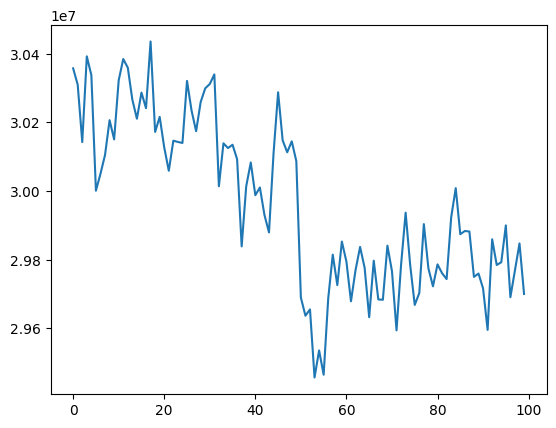

In [66]:
### Note!! There is a sudden change in temperature if you integrate just thetao accross y, x, olevel for piControl, lower 750/500 m. 
# This carries on in the OHC calculation and produces a sudden drop around y 450. 

# It comes from the original data, so nothing wrong with our calculations. 

## **2. Picking up the temperature values for the levels of interest**

In [27]:
## # picking up the area between surf.- 750m and 750-bottom

thetao_upper_750_ipsl_pi = thetao_K_piControl_ipsl['thetao'].where(thetao_K_piControl_ipsl.olevel <= 750, drop=True)
thetao_upper_750_ipsl_x4 = thetao_K_x4CO2_ipsl['thetao'].where(thetao_K_x4CO2_ipsl.olevel <= 750, drop=True)

thetao_lower_750_ipsl_pi = thetao_K_piControl_ipsl['thetao'].where(thetao_K_piControl_ipsl.olevel > 750, drop=True)
thetao_lower_750_ipsl_x4 = thetao_K_x4CO2_ipsl['thetao'].where(thetao_K_x4CO2_ipsl.olevel > 750, drop=True)

# picking up the area between surf.- 500m and 500-bottom

thetao_upper_500_ipsl_pi = thetao_K_piControl_ipsl['thetao'].where(thetao_K_piControl_ipsl.olevel <= 500, drop=True)
thetao_upper_500_ipsl_x4 = thetao_K_x4CO2_ipsl['thetao'].where(thetao_K_x4CO2_ipsl.olevel <= 500, drop=True)

thetao_lower_500_ipsl_pi = thetao_K_piControl_ipsl['thetao'].where(thetao_K_piControl_ipsl.olevel > 500, drop=True)
thetao_lower_500_ipsl_x4 = thetao_K_x4CO2_ipsl['thetao'].where(thetao_K_x4CO2_ipsl.olevel > 500, drop=True)

## **3. Preparing for the integration**

### **3.1. Getting the values of the integrating area from NIRD**

We will multiply this with dz later to get dV.

Note that the dV can be acquired directy from the volcello parameter. But it is not available for all 3 models. 

In [33]:
os.chdir(f'/datalake/NS9560K/ESGF/CMIP6/CMIP/IPSL/IPSL-CM6A-LR/piControl/r1i1p1f1/Ofx/areacello/gn/latest')

areacello_ipsl = xr.open_dataset('areacello_Ofx_IPSL-CM6A-LR_piControl_r1i1p1f1_gn.nc')
areacello_ipsl = areacello_ipsl['areacello']

### **3.2. Getting dZ**

In [34]:
# Bounds
lev_bounds_ipsl = yearly_thetao.olevel_bounds[0, :, :]

#dask compute
lev_bounds_ipsl = lev_bounds_ipsl.compute() 

## 750 m checkpoint

upper_750_ipsl = lev_bounds_ipsl.where(lev_bounds_ipsl.olevel <= 750, drop = True) #upper level bounds, up to 750 m
lower_750_ipsl = lev_bounds_ipsl.where(lev_bounds_ipsl.olevel > 750, drop = True) #lower level bounds, deeper than 750m

# Finding the integrating step 

delta_upper_750_ipsl = abs(upper_750_ipsl[:, 1] - upper_750_ipsl[:, 0])
delta_lower_750_ipsl = abs(lower_750_ipsl[:, 1] - lower_750_ipsl[:, 0])

## 500 m checkpoint

upper_500_ipsl = lev_bounds_ipsl.where(lev_bounds_ipsl.olevel <= 500, drop = True) #upper level bounds, up to 500 m
lower_500_ipsl = lev_bounds_ipsl.where(lev_bounds_ipsl.olevel > 500, drop = True) #lower level bounds, deeper than 500m

# Finding the integrating step 

delta_upper_500_ipsl = abs(upper_500_ipsl[:, 1] - upper_500_ipsl[:, 0])
delta_lower_500_ipsl = abs(lower_500_ipsl[:, 1] - lower_500_ipsl[:, 0])

### **3.3. Caluclating dV**

In [35]:
# Caluclating dV

dV_upper_750_ipsl = delta_upper_750_ipsl * areacello_ipsl
dV_lower_750_ipsl = delta_lower_750_ipsl * areacello_ipsl
dV_upper_500_ipsl = delta_upper_500_ipsl * areacello_ipsl
dV_lower_500_ipsl = delta_lower_500_ipsl * areacello_ipsl

## **4. Calculating, saving and loading the OHC**

In [36]:
# 750m 
weighted_temperature_upper_750_pi_ipsl = thetao_upper_750_ipsl_pi * dV_upper_750_ipsl
ohc_upper_750_pi_ipsl_dV = ohc_funct_dV('IPSL-CM6A-LR', weighted_temperature_upper_750_pi_ipsl)

weighted_temperature_upper_750_x4_ipsl = thetao_upper_750_ipsl_x4 * dV_upper_750_ipsl
ohc_upper_750_x4_ipsl_dV = ohc_funct_dV('IPSL-CM6A-LR', weighted_temperature_upper_750_x4_ipsl)

weighted_temperature_lower_750_pi_ipsl = thetao_lower_750_ipsl_pi * dV_lower_750_ipsl
ohc_lower_750_pi_ipsl_dV = ohc_funct_dV('IPSL-CM6A-LR', weighted_temperature_lower_750_pi_ipsl)

weighted_temperature_lower_750_x4_ipsl = thetao_lower_750_ipsl_x4 * dV_lower_750_ipsl
ohc_lower_750_x4_ipsl_dV = ohc_funct_dV('IPSL-CM6A-LR', weighted_temperature_lower_750_x4_ipsl)

# 500 m 
weighted_temperature_upper_500_pi_ipsl = thetao_upper_500_ipsl_pi * dV_upper_500_ipsl
ohc_upper_500_pi_ipsl_dV = ohc_funct_dV('IPSL-CM6A-LR', weighted_temperature_upper_500_pi_ipsl)

weighted_temperature_upper_500_x4_ipsl = thetao_upper_500_ipsl_x4 * dV_upper_500_ipsl
ohc_upper_500_x4_ipsl_dV = ohc_funct_dV('IPSL-CM6A-LR', weighted_temperature_upper_500_x4_ipsl)

weighted_temperature_lower_500_pi_ipsl = thetao_lower_500_ipsl_pi * dV_lower_500_ipsl
ohc_lower_500_pi_ipsl_dV = ohc_funct_dV('IPSL-CM6A-LR', weighted_temperature_lower_500_pi_ipsl)

weighted_temperature_lower_500_x4_ipsl = thetao_lower_500_ipsl_x4 * dV_lower_500_ipsl
ohc_lower_500_x4_ipsl_dV = ohc_funct_dV('IPSL-CM6A-LR', weighted_temperature_lower_500_x4_ipsl)

In [37]:
save_dir = '/nird/home/chrikap/data/OHC_data/IPSL-CM6A-LR_dV'

f_ohc_upper_750_pi_ipsl_dV = f"{save_dir}/ohc_upper_750_pi_ipsl_dV.npy"
f_ohc_upper_750_x4_ipsl_dV = f"{save_dir}/ohc_upper_750_x4_ipsl_dV.npy"
f_ohc_lower_750_pi_ipsl_dV = f"{save_dir}/ohc_lower_750_pi_ipsl_dV.npy"
f_ohc_lower_750_x4_ipsl_dV = f"{save_dir}/ohc_lower_750_x4_ipsl_dV.npy"
f_ohc_upper_500_pi_ipsl_dV = f"{save_dir}/ohc_upper_500_pi_ipsl_dV.npy"
f_ohc_upper_500_x4_ipsl_dV = f"{save_dir}/ohc_upper_500_x4_ipsl_dV.npy"
f_ohc_lower_500_pi_ipsl_dV = f"{save_dir}/ohc_lower_500_pi_ipsl_dV.npy"
f_ohc_lower_500_x4_ipsl_dV = f"{save_dir}/ohc_lower_500_x4_ipsl_dV.npy"

with ProgressBar():
    np.save(f_ohc_upper_750_pi_ipsl_dV, ohc_upper_750_pi_ipsl_dV)
    np.save(f_ohc_upper_750_x4_ipsl_dV, ohc_upper_750_x4_ipsl_dV)
    np.save(f_ohc_lower_750_pi_ipsl_dV, ohc_lower_750_pi_ipsl_dV)
    np.save(f_ohc_lower_750_x4_ipsl_dV, ohc_lower_750_x4_ipsl_dV)
    np.save(f_ohc_upper_500_pi_ipsl_dV, ohc_upper_500_pi_ipsl_dV)
    np.save(f_ohc_upper_500_x4_ipsl_dV, ohc_upper_500_x4_ipsl_dV)
    np.save(f_ohc_lower_500_pi_ipsl_dV, ohc_lower_500_pi_ipsl_dV)
    np.save(f_ohc_lower_500_x4_ipsl_dV, ohc_lower_500_x4_ipsl_dV)

[########################################] | 100% Completed | 22m 30s
[########################################] | 100% Completed | 25m 43s
[########################################] | 100% Completed | 24m 20s
[########################################] | 100% Completed | 25m 44s
[########################################] | 100% Completed | 24m 17s
[########################################] | 100% Completed | 25m 44s
[########################################] | 100% Completed | 24m 16s
[########################################] | 100% Completed | 25m 42s


In [4]:
load_dir = '/nird/home/chrikap/data/OHC_data/IPSL-CM6A-LR_dV'

ohc_upper_750_pi_ipsl_dV = np.load(f'{load_dir}/ohc_upper_750_pi_ipsl_dV.npy')
ohc_upper_750_x4_ipsl_dV = np.load(f'{load_dir}/ohc_upper_750_x4_ipsl_dV.npy')
ohc_lower_750_pi_ipsl_dV = np.load(f'{load_dir}/ohc_lower_750_pi_ipsl_dV.npy')
ohc_lower_750_x4_ipsl_dV = np.load(f'{load_dir}/ohc_lower_750_x4_ipsl_dV.npy')
ohc_upper_500_pi_ipsl_dV = np.load(f'{load_dir}/ohc_upper_500_pi_ipsl_dV.npy')
ohc_upper_500_x4_ipsl_dV = np.load(f'{load_dir}/ohc_upper_500_x4_ipsl_dV.npy')
ohc_lower_500_pi_ipsl_dV = np.load(f'{load_dir}/ohc_lower_500_pi_ipsl_dV.npy')
ohc_lower_500_x4_ipsl_dV = np.load(f'{load_dir}/ohc_lower_500_x4_ipsl_dV.npy')

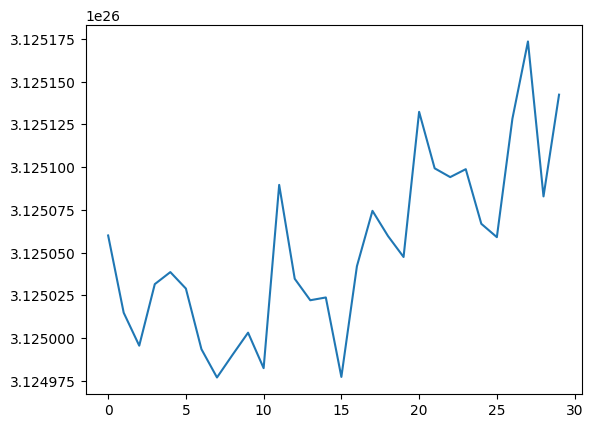

In [10]:
t = np.arange(0, 30)
plt.plot(t, ohc_upper_750_pi_ipsl_dV[0:30])

## **5. Apply a rolling mean**

In [5]:
roll_ohc_upper_750_pi_ipsl_dV = rolling_average_ts(ohc_upper_750_pi_ipsl_dV, 11)
roll_ohc_upper_750_x4_ipsl_dV = rolling_average_ts(ohc_upper_750_x4_ipsl_dV, 11)
roll_ohc_lower_750_pi_ipsl_dV = rolling_average_ts(ohc_lower_750_pi_ipsl_dV, 11)
roll_ohc_lower_750_x4_ipsl_dV = rolling_average_ts(ohc_lower_750_x4_ipsl_dV, 11)
roll_ohc_upper_500_pi_ipsl_dV = rolling_average_ts(ohc_upper_500_pi_ipsl_dV, 11)
roll_ohc_upper_500_x4_ipsl_dV = rolling_average_ts(ohc_upper_500_x4_ipsl_dV, 11)
roll_ohc_lower_500_pi_ipsl_dV = rolling_average_ts(ohc_lower_500_pi_ipsl_dV, 11)
roll_ohc_lower_500_x4_ipsl_dV = rolling_average_ts(ohc_lower_500_x4_ipsl_dV, 11)

# **C. CESM2**

## **1. Importing the potential temperature from NIRD and changing the units from C-> K**

In [6]:
experiments = ['piControl', 'abrupt-4xCO2']

for experiment in experiments:
            
    folder_path = f'/datalake/NS9560K/ESGF/CMIP6/CMIP/NCAR/CESM2/{experiment}/r1i1p1f1/Omon/thetao/gn/latest/'

    file_names = sorted(os.listdir(folder_path))
    
    datasets = [xr.open_dataset(os.path.join(folder_path, file_name), chunks={'time': 12}) for file_name in file_names if file_name.endswith('.nc')]
    
    # Merge all the datasets in the list along the same dimension
    merged_datasets = xr.concat(datasets, dim='time')
    ds = merged_datasets.isel(time=slice(0, 999*12))

    ds = ds.chunk({
        "time": 120,      # 1 year
        "lev": 10,    # reasonable vertical chunk
        "nlat": 100,
        "nlon": 100
    })

    yearly_thetao = yearly_avg_manual('CESM2', ds)

    if experiment == 'piControl':
    
        thetao_piControl_cesm2 = yearly_thetao
    else: 
        thetao_x4CO2_cesm2 = yearly_thetao

In [7]:
thetao_K_piControl_cesm2 = thetao_piControl_cesm2 + 273.15
thetao_K_x4CO2_cesm2 = thetao_x4CO2_cesm2 + 273.15

## **2. Picking up the temperature values for the levels of interest**

In [8]:
## # picking up the area between surf.- 750m and 750-bottom

thetao_upper_750_cesm2_pi = thetao_piControl_cesm2['thetao'].where(thetao_piControl_cesm2.lev <= 750*100, drop=True)
thetao_upper_750_cesm2_x4 = thetao_x4CO2_cesm2['thetao'].where(thetao_x4CO2_cesm2.lev <= 750*100, drop=True)

thetao_lower_750_cesm2_pi = thetao_piControl_cesm2['thetao'].where(thetao_piControl_cesm2.lev > 750*100, drop=True)
thetao_lower_750_cesm2_x4 = thetao_x4CO2_cesm2['thetao'].where(thetao_x4CO2_cesm2.lev > 750*100, drop=True)

# picking up the area between surf.- 500m and 500-bottom

thetao_upper_500_cesm2_pi = thetao_piControl_cesm2['thetao'].where(thetao_piControl_cesm2.lev <= 500*100, drop=True)
thetao_upper_500_cesm2_x4 = thetao_x4CO2_cesm2['thetao'].where(thetao_x4CO2_cesm2.lev <= 500*100, drop=True)

thetao_lower_500_cesm2_pi = thetao_piControl_cesm2['thetao'].where(thetao_piControl_cesm2.lev > 500*100, drop=True)
thetao_lower_500_cesm2_x4 = thetao_x4CO2_cesm2['thetao'].where(thetao_x4CO2_cesm2.lev > 500*100, drop=True)

## **3. Preparing for the integration**

### **3.1. Getting the values of the integrating area from NIRD**

In [10]:
os.chdir(f'/datalake/NS9560K/ESGF/CMIP6/CMIP/NCAR/CESM2/piControl/r1i1p1f1/Ofx/areacello/gn/latest')

areacello_cesm2 = xr.open_dataset('areacello_Ofx_CESM2_piControl_r1i1p1f1_gn.nc')
areacello_cesm2 = areacello_cesm2['areacello']

### **3.2. Getting dZ**

In [11]:
# Bounds
lev_bounds_cesm2 = yearly_thetao.lev_bnds[0, :, :]

#dask compute
lev_bounds_cesm2 = lev_bounds_cesm2.compute() 

## 750 m checkpoint

upper_750_cesm2 = lev_bounds_cesm2.where(lev_bounds_cesm2 <= 750, drop = True) #upper level bounds, up to 750 m
lower_750_cesm2 = lev_bounds_cesm2.where(lev_bounds_cesm2 > 750, drop = True) #lower level bounds, deeper than 750m

# Finding the integrating step 

delta_upper_750_cesm2 = abs(upper_750_cesm2[:, 1] - upper_750_cesm2[:, 0])
delta_lower_750_cesm2 = abs(lower_750_cesm2[:, 1] - lower_750_cesm2[:, 0])

## 500 m checkpoint

upper_500_cesm2 = lev_bounds_cesm2.where(lev_bounds_cesm2 <= 500, drop = True) #upper level bounds, up to 500 m
lower_500_cesm2 = lev_bounds_cesm2.where(lev_bounds_cesm2 > 500, drop = True) #lower level bounds, deeper than 500m

# Finding the integrating step 

delta_upper_500_cesm2 = abs(upper_500_cesm2[:, 1] - upper_500_cesm2[:, 0])
delta_lower_500_cesm2 = abs(lower_500_cesm2[:, 1] - lower_500_cesm2[:, 0])

### **3.3. Caluclating dV**

In [13]:
# Caluclating dV

dV_upper_750_cesm2 = delta_upper_750_cesm2 * areacello_cesm2
dV_lower_750_cesm2 = delta_lower_750_cesm2 * areacello_cesm2
dV_upper_500_cesm2 = delta_upper_500_cesm2 * areacello_cesm2
dV_lower_500_cesm2 = delta_lower_500_cesm2 * areacello_cesm2

## **4. Calculating, saving and loading the OHC**

In [14]:
# 750m 
weighted_temperature_upper_750_pi_cesm2 = thetao_upper_750_cesm2_pi * dV_upper_750_cesm2
ohc_upper_750_pi_cesm2_dV = ohc_funct_dV('CESM2', weighted_temperature_upper_750_pi_cesm2)

weighted_temperature_upper_750_x4_cesm2 = thetao_upper_750_cesm2_x4 * dV_upper_750_cesm2
ohc_upper_750_x4_cesm2_dV = ohc_funct_dV('CESM2', weighted_temperature_upper_750_x4_cesm2)

weighted_temperature_lower_750_pi_cesm2 = thetao_lower_750_cesm2_pi * dV_lower_750_cesm2
ohc_lower_750_pi_cesm2_dV = ohc_funct_dV('CESM2', weighted_temperature_lower_750_pi_cesm2)

weighted_temperature_lower_750_x4_cesm2 = thetao_lower_750_cesm2_x4 * dV_lower_750_cesm2
ohc_lower_750_x4_cesm2_dV = ohc_funct_dV('CESM2', weighted_temperature_lower_750_x4_cesm2)

# 500 m 

weighted_temperature_upper_500_pi_cesm2 = thetao_upper_500_cesm2_pi * dV_upper_500_cesm2
ohc_upper_500_pi_cesm2_dV = ohc_funct_dV('CESM2', weighted_temperature_upper_500_pi_cesm2)

weighted_temperature_upper_500_x4_cesm2 = thetao_upper_500_cesm2_x4 * dV_upper_500_cesm2
ohc_upper_500_x4_cesm2_dV = ohc_funct_dV('CESM2', weighted_temperature_upper_500_x4_cesm2)

weighted_temperature_lower_500_pi_cesm2 = thetao_lower_500_cesm2_pi * dV_lower_500_cesm2
ohc_lower_500_pi_cesm2_dV = ohc_funct_dV('CESM2', weighted_temperature_lower_500_pi_cesm2)

weighted_temperature_lower_500_x4_cesm2 = thetao_lower_500_cesm2_x4 * dV_lower_500_cesm2
ohc_lower_500_x4_cesm2_dV = ohc_funct_dV('CESM2', weighted_temperature_lower_500_x4_cesm2)

In [15]:
save_dir = '/nird/home/chrikap/data/OHC_data/CESM2_dV'

f_ohc_upper_750_pi_cesm2_dV = f"{save_dir}/ohc_upper_750_pi_cesm2_dV.npy"
f_ohc_upper_750_x4_cesm2_dV = f"{save_dir}/ohc_upper_750_x4_cesm2_dV.npy"
f_ohc_lower_750_pi_cesm2_dV = f"{save_dir}/ohc_lower_750_pi_cesm2_dV.npy"
f_ohc_lower_750_x4_cesm2_dV = f"{save_dir}/ohc_lower_750_x4_cesm2_dV.npy"
f_ohc_upper_500_pi_cesm2_dV = f"{save_dir}/ohc_upper_500_pi_cesm2_dV.npy"
f_ohc_upper_500_x4_cesm2_dV = f"{save_dir}/ohc_upper_500_x4_cesm2_dV.npy"
f_ohc_lower_500_pi_cesm2_dV = f"{save_dir}/ohc_lower_500_pi_cesm2_dV.npy"
f_ohc_lower_500_x4_cesm2_dV = f"{save_dir}/ohc_lower_500_x4_cesm2_dV.npy"

with ProgressBar():
    np.save(f_ohc_upper_750_pi_cesm2_dV, ohc_upper_750_pi_cesm2_dV)
    np.save(f_ohc_upper_750_x4_cesm2_dV, ohc_upper_750_x4_cesm2_dV)
    np.save(f_ohc_lower_750_pi_cesm2_dV, ohc_lower_750_pi_cesm2_dV)
    np.save(f_ohc_lower_750_x4_cesm2_dV, ohc_lower_750_x4_cesm2_dV)
    np.save(f_ohc_upper_500_pi_cesm2_dV, ohc_upper_500_pi_cesm2_dV)
    np.save(f_ohc_upper_500_x4_cesm2_dV, ohc_upper_500_x4_cesm2_dV)
    np.save(f_ohc_lower_500_pi_cesm2_dV, ohc_lower_500_pi_cesm2_dV)
    np.save(f_ohc_lower_500_x4_cesm2_dV, ohc_lower_500_x4_cesm2_dV)

[########################################] | 100% Completed | 25m 4ss
[########################################] | 100% Completed | 24m 18s
[########################################] | 100% Completed | 13m 56s
[########################################] | 100% Completed | 12m 48s
[########################################] | 100% Completed | 23m 16s
[########################################] | 100% Completed | 23m 14s
[########################################] | 100% Completed | 12m 40s
[########################################] | 100% Completed | 11m 52s


In [6]:
load_dir = '/nird/home/chrikap/data/OHC_data/CESM2_dV'

ohc_upper_750_pi_cesm2_dV = np.load(f'{load_dir}/ohc_upper_750_pi_cesm2_dV.npy')
ohc_upper_750_x4_cesm2_dV = np.load(f'{load_dir}/ohc_upper_750_x4_cesm2_dV.npy')
ohc_lower_750_pi_cesm2_dV = np.load(f'{load_dir}/ohc_lower_750_pi_cesm2_dV.npy')
ohc_lower_750_x4_cesm2_dV = np.load(f'{load_dir}/ohc_lower_750_x4_cesm2_dV.npy')
ohc_upper_500_pi_cesm2_dV = np.load(f'{load_dir}/ohc_upper_500_pi_cesm2_dV.npy')
ohc_upper_500_x4_cesm2_dV = np.load(f'{load_dir}/ohc_upper_500_x4_cesm2_dV.npy')
ohc_lower_500_pi_cesm2_dV = np.load(f'{load_dir}/ohc_lower_500_pi_cesm2_dV.npy')
ohc_lower_500_x4_cesm2_dV = np.load(f'{load_dir}/ohc_lower_500_x4_cesm2_dV.npy')

## **5. Apply a rolling mean**

In [7]:
roll_ohc_upper_750_pi_cesm2_dV = rolling_average_ts(ohc_upper_750_pi_cesm2_dV, 11)
roll_ohc_upper_750_x4_cesm2_dV = rolling_average_ts(ohc_upper_750_x4_cesm2_dV, 11)
roll_ohc_lower_750_pi_cesm2_dV = rolling_average_ts(ohc_lower_750_pi_cesm2_dV, 11)
roll_ohc_lower_750_x4_cesm2_dV = rolling_average_ts(ohc_lower_750_x4_cesm2_dV, 11)
roll_ohc_upper_500_pi_cesm2_dV = rolling_average_ts(ohc_upper_500_pi_cesm2_dV, 11)
roll_ohc_upper_500_x4_cesm2_dV = rolling_average_ts(ohc_upper_500_x4_cesm2_dV, 11)
roll_ohc_lower_500_pi_cesm2_dV = rolling_average_ts(ohc_lower_500_pi_cesm2_dV, 11)
roll_ohc_lower_500_x4_cesm2_dV = rolling_average_ts(ohc_lower_500_x4_cesm2_dV, 11)

# **D. Plotting everything**

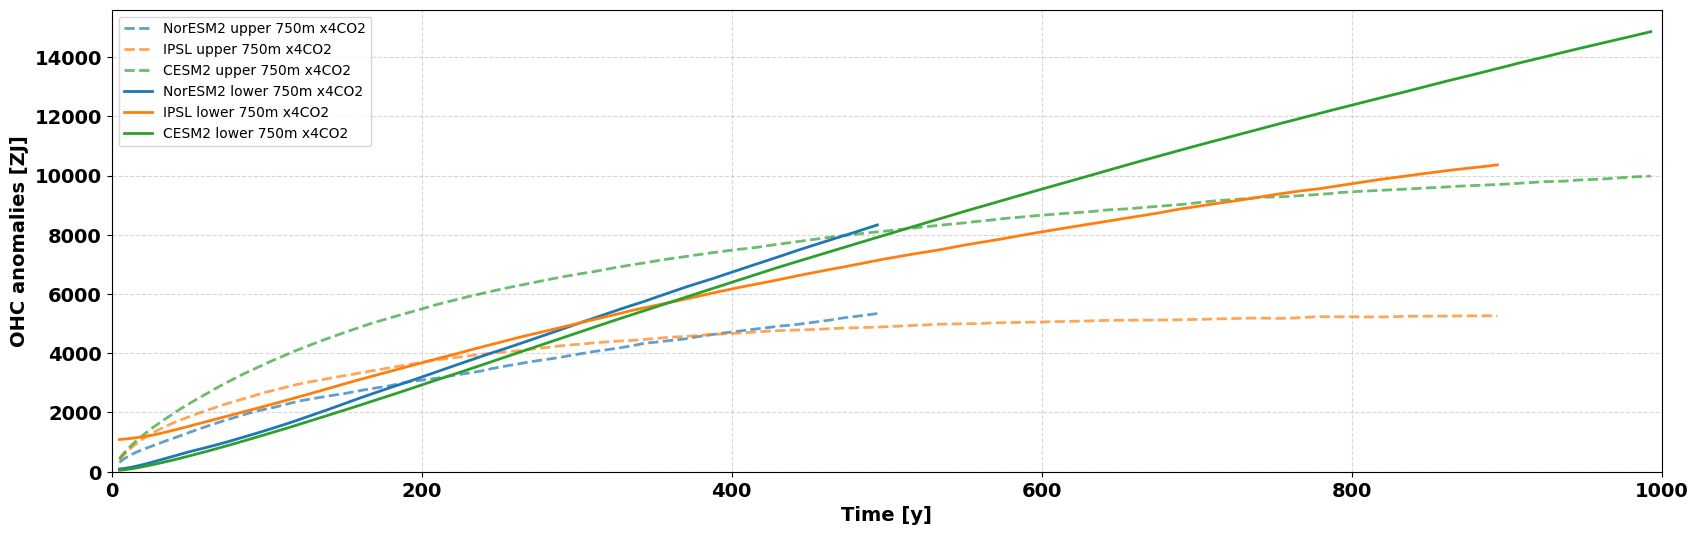

In [18]:
time_roll_noresm2 = np.arange(5, 495)
time_roll_ipsl = np.arange(5, 895)
time_roll_cesm2 = np.arange(5, 994)

fig = plt.subplots(figsize=(20, 6))

## upper

plt.plot(time_roll_noresm2, (roll_ohc_upper_750_x4_noresm2_dV - np.mean(roll_ohc_upper_750_pi_noresm2_dV))/10**21, '--', color='tab:blue', alpha = 0.7, linewidth=2, label='NorESM2 upper 750m x4CO2')
plt.plot(time_roll_ipsl, (roll_ohc_upper_750_x4_ipsl_dV - np.mean(roll_ohc_upper_750_pi_ipsl_dV))/10**21, '--', color='tab:orange', alpha = 0.7, linewidth=2, label='IPSL upper 750m x4CO2')
plt.plot(time_roll_cesm2, (roll_ohc_upper_750_x4_cesm2_dV - np.mean(roll_ohc_upper_750_pi_cesm2_dV))/10**21, '--', color='tab:green', alpha = 0.7, linewidth=2, label='CESM2 upper 750m x4CO2')


# lower

plt.plot(time_roll_noresm2, (roll_ohc_lower_750_x4_noresm2_dV - np.mean(roll_ohc_lower_750_pi_noresm2_dV))/10**21, color='tab:blue', linewidth=2, label='NorESM2 lower 750m x4CO2')
plt.plot(time_roll_ipsl, (roll_ohc_lower_750_x4_ipsl_dV - np.mean(roll_ohc_lower_750_pi_ipsl_dV))/10**21, color='tab:orange', linewidth=2, label='IPSL lower 750m x4CO2')
plt.plot(time_roll_cesm2, (roll_ohc_lower_750_x4_cesm2_dV - np.mean(roll_ohc_lower_750_pi_cesm2_dV))/10**21, color='tab:green', linewidth=2, label='CESM2 lower 750m x4CO2')



plt.xlabel('Time [y]', fontsize=14, fontweight='bold')
plt.ylabel('OHC anomalies [ZJ]', fontsize=14, fontweight='bold')
plt.tick_params(axis='both', which='major', labelsize=14)

plt.xlim(0, 1000)
plt.ylim(0, )
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(loc = 'upper left')
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
plt.show()

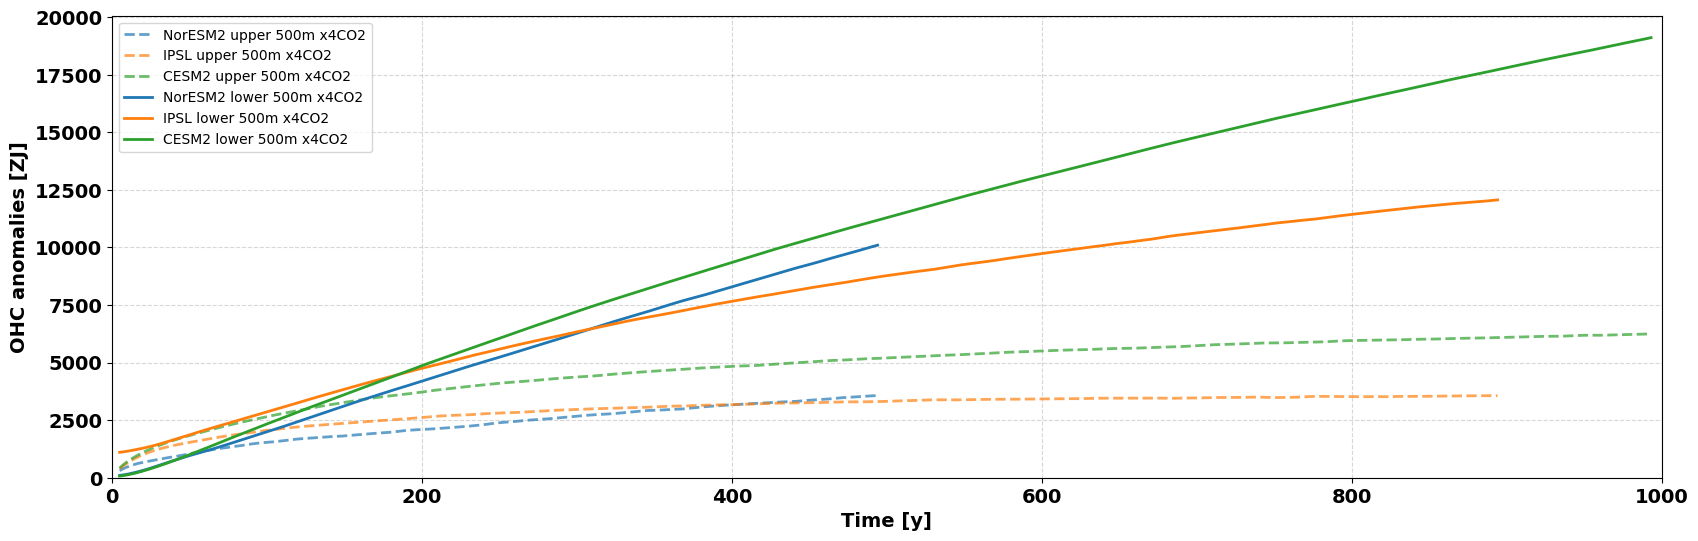

In [19]:
time_roll_noresm2 = np.arange(5, 495)
time_roll_ipsl = np.arange(5, 895)
time_roll_cesm2 = np.arange(5, 994)

fig = plt.subplots(figsize=(20, 6))

## upper

plt.plot(time_roll_noresm2, (roll_ohc_upper_500_x4_noresm2_dV - np.mean(roll_ohc_upper_500_pi_noresm2_dV))/10**21, '--', color='tab:blue', alpha = 0.7, linewidth=2, label='NorESM2 upper 500m x4CO2')
plt.plot(time_roll_ipsl, (roll_ohc_upper_500_x4_ipsl_dV - np.mean(roll_ohc_upper_500_pi_ipsl_dV))/10**21, '--', color='tab:orange', alpha = 0.7, linewidth=2, label='IPSL upper 500m x4CO2')
plt.plot(time_roll_cesm2, (roll_ohc_upper_500_x4_cesm2_dV - np.mean(roll_ohc_upper_500_pi_cesm2_dV))/10**21, '--', color='tab:green', alpha = 0.7, linewidth=2, label='CESM2 upper 500m x4CO2')

# lower

plt.plot(time_roll_noresm2, (roll_ohc_lower_500_x4_noresm2_dV - np.mean(roll_ohc_lower_500_pi_noresm2_dV))/10**21, color='tab:blue', linewidth=2, label='NorESM2 lower 500m x4CO2')
plt.plot(time_roll_ipsl, (roll_ohc_lower_500_x4_ipsl_dV - np.mean(roll_ohc_lower_500_pi_ipsl_dV))/10**21, color='tab:orange', linewidth=2, label='IPSL lower 500m x4CO2')
plt.plot(time_roll_cesm2, (roll_ohc_lower_500_x4_cesm2_dV - np.mean(roll_ohc_lower_500_pi_cesm2_dV))/10**21, color='tab:green', linewidth=2, label='CESM2 lower 500m x4CO2')

plt.xlabel('Time [y]', fontsize=14, fontweight='bold')
plt.ylabel('OHC anomalies [ZJ]', fontsize=14, fontweight='bold')
plt.tick_params(axis='both', which='major', labelsize=14)

plt.xlim(0, 1000)
plt.ylim(0, )
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(loc = 'upper left')
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
plt.show()